# Prediction Intervals and Uncertainty for Short-Term Estimated WEC Power Forecasts

This notebook extends the short-term point-forecasting baselines from [Notebook 03](03_forecasting_baselines.ipynb) by evaluating prediction intervals for the estimated WEC power signal.

Notebook 03 focused on point forecasts for the normalized estimated WEC power target, `wec_power_norm_estimated`, using a compact power-only autoregressive benchmark. The saved calibration and test predictions from that notebook provide the residual basis for the uncertainty analysis here.

The goal of this notebook is to evaluate whether simple empirical prediction intervals provide useful uncertainty estimates across forecast horizons, models, and higher-ramp periods. The main evaluation remains on the normalized WEC-power scale, while selected 250 kW-scale values are used later for physical interpretation of the generic WEC proxy.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


# Paths are relative to the notebooks/ directory.
NOTEBOOK_ID = "notebook_04"

DATA_DIR = Path("../data")
OUTPUTS_DIR = Path("../outputs")

INPUT_FORECAST_PATH = OUTPUTS_DIR / "notebook_03" / "forecast_predictions.parquet"
INPUT_FOLDS_PATH = DATA_DIR / "processed" / "folds" / "forecast_folds.parquet"

TABLES_DIR = OUTPUTS_DIR / "tables" / NOTEBOOK_ID
FIGURES_DIR = OUTPUTS_DIR / "figures" / NOTEBOOK_ID
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / NOTEBOOK_ID

for path in [TABLES_DIR, FIGURES_DIR, NOTEBOOK_OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RATED_POWER_KW = 250.0

INTERVAL_LEVELS = [0.80, 0.90, 0.95]
MAIN_INTERVAL_LEVEL = 0.90

PRIMARY_MODELS = ["Persistence", "RollingMean", "Ridge"]
CONTRAST_MODELS = ["RandomForest"]
ALL_MODELS = PRIMARY_MODELS + CONTRAST_MODELS

## Notebook 03 forecast outputs and analysis scope

Prediction intervals are built from the selected calibration and test predictions saved by [Notebook 03](03_forecasting_baselines.ipynb).

The calibration split is used to estimate residual-based interval rules. The test split is reserved for final prediction-interval evaluation. The main analysis focuses on Persistence, RollingMean, and Ridge, while RandomForest is retained only as a contrast model because it was slower and not competitive in the point-forecast benchmark.

In [3]:
forecast_df = pd.read_parquet(INPUT_FORECAST_PATH)
folds_df = pd.read_parquet(INPUT_FOLDS_PATH)

required_columns = [
    "sample_id",
    "origin_time",
    "target_time",
    "horizon_steps",
    "horizon_hours",
    "horizon_label",
    "fold_id",
    "split",
    "model",
    "y_true_norm",
    "y_pred_norm",
    "error_norm",
    "y_true_kw_250",
    "y_pred_kw_250",
    "error_kw_250",
]

missing_columns = sorted(set(required_columns) - set(forecast_df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns in forecast predictions: {missing_columns}")

forecast_df = forecast_df[required_columns].copy()

forecast_df["origin_time"] = pd.to_datetime(forecast_df["origin_time"])
forecast_df["target_time"] = pd.to_datetime(forecast_df["target_time"])

forecast_df = forecast_df[
    forecast_df["split"].isin(["calibration", "test"])
    & forecast_df["model"].isin(ALL_MODELS)
].copy()

forecast_df = forecast_df.sort_values(
    ["horizon_steps", "fold_id", "split", "model", "target_time"]
).reset_index(drop=True)

forecast_df["abs_error_norm"] = forecast_df["error_norm"].abs()

print(f"Loaded forecast predictions: {forecast_df.shape[0]:,} rows")
print(f"Loaded fold definitions: {folds_df.shape[0]:,} rows")

Loaded forecast predictions: 102,396 rows
Loaded fold definitions: 85,299 rows


In [4]:
input_summary = (
    forecast_df
    .groupby(["horizon_steps", "horizon_label", "model", "split"], observed=True)
    .agg(
        n_rows=("sample_id", "size"),
        first_target_time=("target_time", "min"),
        last_target_time=("target_time", "max"),
    )
    .reset_index()
)

input_summary_path = TABLES_DIR / "interval_input_summary.csv"
input_summary.to_csv(input_summary_path, index=False)

display(Markdown("**Notebook 04 input rows by horizon, model, and split**"))
display(Markdown(input_summary.to_markdown(index=False)))

print(f"Saved input summary to: {input_summary_path}")

**Notebook 04 input rows by horizon, model, and split**

|   horizon_steps | horizon_label   | model        | split       |   n_rows | first_target_time   | last_target_time    |
|----------------:|:----------------|:-------------|:------------|---------:|:--------------------|:--------------------|
|               1 | 30 min          | Persistence  | calibration |     3281 | 2025-04-18 16:00:00 | 2025-06-13 12:00:00 |
|               1 | 30 min          | Persistence  | test        |     3289 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               1 | 30 min          | RandomForest | calibration |     3281 | 2025-04-18 16:00:00 | 2025-06-13 12:00:00 |
|               1 | 30 min          | RandomForest | test        |     3289 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               1 | 30 min          | Ridge        | calibration |     3281 | 2025-04-18 16:00:00 | 2025-06-13 12:00:00 |
|               1 | 30 min          | Ridge        | test        |     3289 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               1 | 30 min          | RollingMean  | calibration |     3281 | 2025-04-18 16:00:00 | 2025-06-13 12:00:00 |
|               1 | 30 min          | RollingMean  | test        |     3289 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               2 | 1 h             | Persistence  | calibration |     3250 | 2025-04-18 15:30:00 | 2025-06-13 13:30:00 |
|               2 | 1 h             | Persistence  | test        |     3258 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               2 | 1 h             | RandomForest | calibration |     3250 | 2025-04-18 15:30:00 | 2025-06-13 13:30:00 |
|               2 | 1 h             | RandomForest | test        |     3258 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               2 | 1 h             | Ridge        | calibration |     3250 | 2025-04-18 15:30:00 | 2025-06-13 13:30:00 |
|               2 | 1 h             | Ridge        | test        |     3258 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               2 | 1 h             | RollingMean  | calibration |     3250 | 2025-04-18 15:30:00 | 2025-06-13 13:30:00 |
|               2 | 1 h             | RollingMean  | test        |     3258 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               4 | 2 h             | Persistence  | calibration |     3189 | 2025-04-18 13:30:00 | 2025-06-13 16:30:00 |
|               4 | 2 h             | Persistence  | test        |     3195 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               4 | 2 h             | RandomForest | calibration |     3189 | 2025-04-18 13:30:00 | 2025-06-13 16:30:00 |
|               4 | 2 h             | RandomForest | test        |     3195 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               4 | 2 h             | Ridge        | calibration |     3189 | 2025-04-18 13:30:00 | 2025-06-13 16:30:00 |
|               4 | 2 h             | Ridge        | test        |     3195 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               4 | 2 h             | RollingMean  | calibration |     3189 | 2025-04-18 13:30:00 | 2025-06-13 16:30:00 |
|               4 | 2 h             | RollingMean  | test        |     3195 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               8 | 4 h             | Persistence  | calibration |     3065 | 2025-04-18 11:00:00 | 2025-06-14 15:00:00 |
|               8 | 4 h             | Persistence  | test        |     3072 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               8 | 4 h             | RandomForest | calibration |     3065 | 2025-04-18 11:00:00 | 2025-06-14 15:00:00 |
|               8 | 4 h             | RandomForest | test        |     3072 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               8 | 4 h             | Ridge        | calibration |     3065 | 2025-04-18 11:00:00 | 2025-06-14 15:00:00 |
|               8 | 4 h             | Ridge        | test        |     3072 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               8 | 4 h             | RollingMean  | calibration |     3065 | 2025-04-18 11:00:00 | 2025-06-14 15:00:00 |
|               8 | 4 h             | RollingMean  | test        |     3072 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |

Saved input summary to: ../outputs/tables/notebook_04/interval_input_summary.csv


## Residual basis for interval calibration

Notebook 04 uses the calibration residuals saved by Notebook 03 as the empirical basis for prediction intervals. Before constructing intervals, the calibration residual spread is visualized by model and forecast horizon.

This provides a simple check of whether interval widths should depend on horizon and model choice.

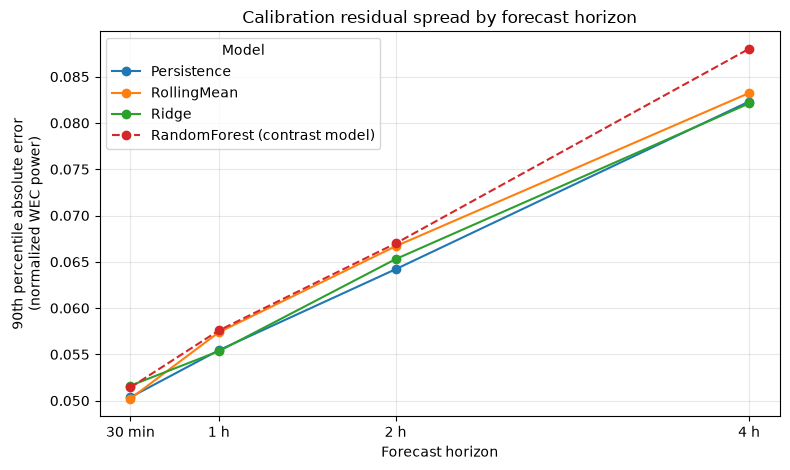

Saved calibration residual spread figure to: ../outputs/figures/notebook_04/calibration_residual_spread_by_horizon.png


In [8]:
plot_df = (
    forecast_df
    .query("split == 'calibration'")
    .groupby(
        ["horizon_steps", "horizon_hours", "horizon_label", "model"],
        observed=True,
    )
    .agg(
        p90_abs_error_norm=("abs_error_norm", lambda x: np.quantile(x.dropna(), 0.90))
    )
    .reset_index()
)

horizon_ticks = (
    plot_df[["horizon_hours", "horizon_label"]]
    .drop_duplicates()
    .sort_values("horizon_hours")
)

fig, ax = plt.subplots(figsize=(8, 4.8))

for model in ALL_MODELS:
    model_df = plot_df[plot_df["model"].eq(model)].sort_values("horizon_steps")
    if model_df.empty:
        continue

    is_contrast = model in CONTRAST_MODELS
    linestyle = "--" if is_contrast else "-"
    label = f"{model} (contrast model)" if is_contrast else model

    ax.plot(
        model_df["horizon_hours"],
        model_df["p90_abs_error_norm"],
        marker="o",
        linestyle=linestyle,
        label=label,
    )

ax.set_title("Calibration residual spread by forecast horizon")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("90th percentile absolute error\n(normalized WEC power)")
ax.set_xticks(horizon_ticks["horizon_hours"])
ax.set_xticklabels(horizon_ticks["horizon_label"])
ax.grid(True, alpha=0.3)
ax.legend(title="Model")

fig.tight_layout()

residual_spread_path = FIGURES_DIR / "calibration_residual_spread_by_horizon.png"
fig.savefig(residual_spread_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved calibration residual spread figure to: {residual_spread_path}")